In [22]:
# Machine Learning Figures

# Purpose:

#Generate publication-quality figures for the machine learning analyses.

#Outputs:

#- figures/ml/confusion_matrix.png
#- figures/ml/top_features.png

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..")

ML_RESULTS_DIR = PROJECT_ROOT / "results" / "ml"
FIGURES_DIR = PROJECT_ROOT / "figures" / "ml"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(ML_RESULTS_DIR.exists())
print(FIGURES_DIR.exists())

True
True


In [24]:
# on charge les résultats 
metrics = pd.read_csv(
    ML_RESULTS_DIR / "classification_metrics.csv",
    index_col=0
)

cm = pd.read_csv(
    ML_RESULTS_DIR / "confusion_matrix.csv",
    index_col=0
)

importance = pd.read_csv(
    ML_RESULTS_DIR / "feature_importance.csv"
)

print(metrics)
print(cm)
print(importance.head())

                          0
accuracy           0.687500
balanced_accuracy  0.682186
precision          0.607143
recall             0.653846
f1                 0.629630
roc_auc            0.727733
                    pred_non_converter  pred_converter
true_non_converter                  27              11
true_converter                       9              17
                          feature  coefficient  abs_coefficient
0        occipital_total_sw_count    -1.191205         1.191205
1  occipital_total_N2_pkpk_amp_uV     0.909597         0.909597
2       frontal_total_slope_0_min     0.860606         0.860606
3     central_total_trans_freq_Hz    -0.842717         0.842717
4    parietal_total_trans_freq_Hz    -0.837975         0.837975


In [25]:
# on vérfie que les variables de performance sont les même qu'à la dernière vérification
#Accuracy ≈ 0.69
#Balanced Accuracy ≈ 0.68

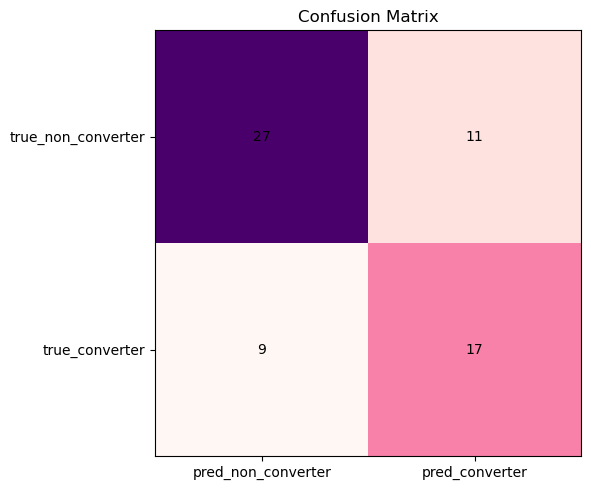

In [26]:
# on créée la figure de matrice de confusion 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    cm.values,
    cmap="RdPu"
)

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(cm.columns)
ax.set_yticklabels(cm.index)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm.iloc[i,j],
            ha="center",
            va="center"
        )

ax.set_title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# figure 2 des top 15 top biomarqueurs 
top15 = (
    importance
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .head(15)
)

top15

,feature,coefficient,abs_coefficient
0,occipital_total_sw_count,-1.191205,1.191205
1,occipital_total_N2_pkpk_amp_uV,0.909597,0.909597
2,frontal_total_slope_0_min,0.860606,0.860606
3,central_total_trans_freq_Hz,-0.842717,0.842717
4,parietal_total_trans_freq_Hz,-0.837975,0.837975
5,parietal_total_N2_freq_Hz,0.808701,0.808701
6,central_total_freq_Hz,-0.805231,0.805231
7,occipital_total_slope_0_min,-0.753945,0.753945
8,occipital_total_N3_pkpk_amp_uV,0.746944,0.746944
9,parietal_total_sw_count,0.744755,0.744755


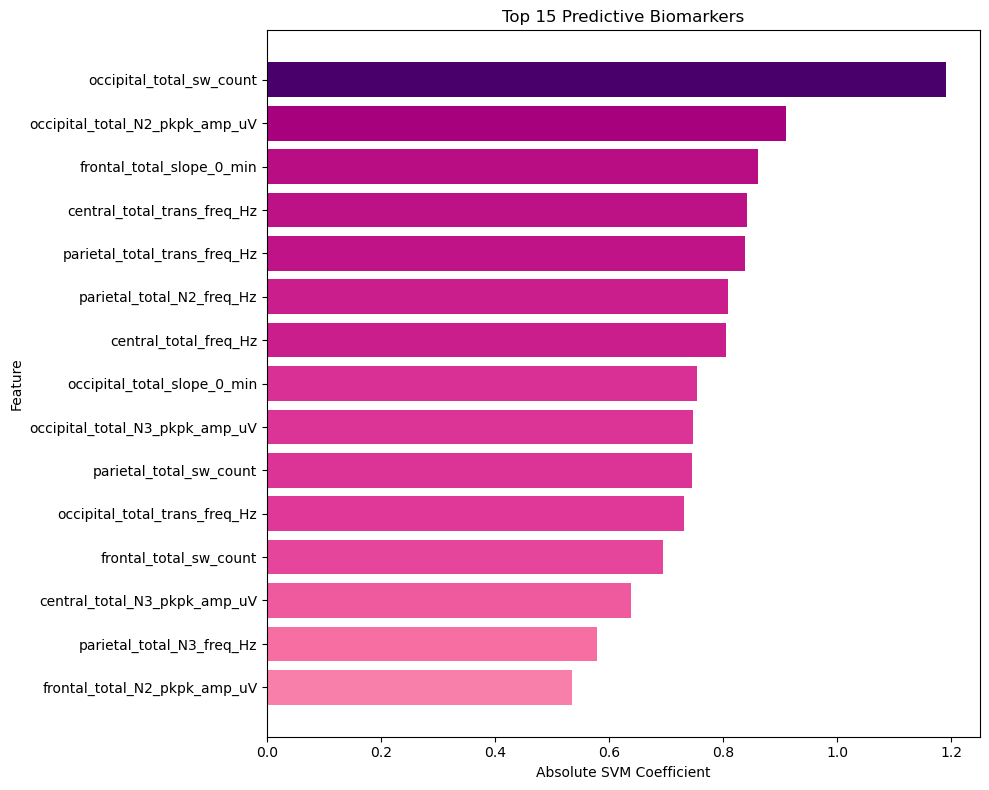

In [28]:
fig, ax = plt.subplots(
    figsize=(10,8)
)

top15 = top15.iloc[::-1]

colors = plt.cm.RdPu(
    top15["abs_coefficient"] /
    top15["abs_coefficient"].max()
)

ax.barh(
    top15["feature"],
    top15["abs_coefficient"],
    color=colors
)

ax.set_xlabel(
    "Absolute SVM Coefficient"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "Top 15 Predictive Biomarkers"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top15_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# la courbe ROC a été ajouté au script de ML 
# je vais maintenant la charger
roc = pd.read_csv(
    ML_RESULTS_DIR / "roc_curve.csv"
)

metrics = pd.read_csv(
    ML_RESULTS_DIR / "classification_metrics.csv",
    index_col=0
)

auc = metrics.loc["roc_auc", "0"]

roc.head()



,fpr,tpr,threshold
0,0.000000,0.000000,inf
1,0.026316,0.000000,2.586255
2,0.052632,0.000000,1.944360
3,0.052632,0.038462,1.439290
4,0.078947,0.038462,1.352683


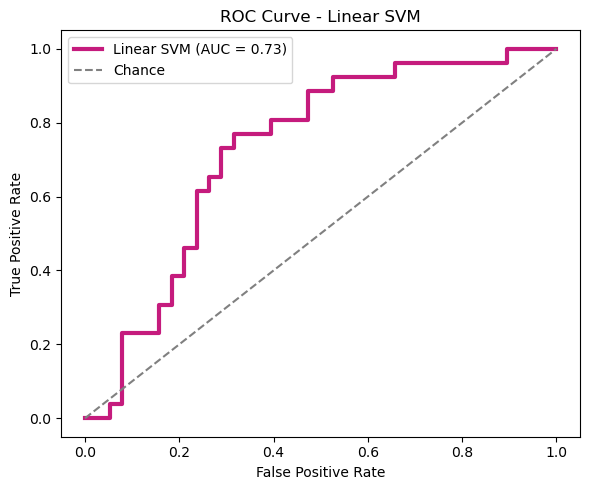

In [30]:
# on créée la figure ROC 
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    roc["fpr"],
    roc["tpr"],
    linewidth=3,
    color="#C51B7D",
    label=f"Linear SVM (AUC = {auc:.2f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label="Chance"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Linear SVM")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# figure dédiée aux biomarqueurs : 
#Figure 4

#Robust Biomarkers Across Models

#This figure shows biomarkers that were ranked among the top 15 features by both Linear SVM and Logistic Regression.

In [32]:
common = pd.read_csv(
    ML_RESULTS_DIR / "common_biomarkers.csv"
)

svm_importance = pd.read_csv(
    ML_RESULTS_DIR / "feature_importance.csv"
)

log_importance = pd.read_csv(
    ML_RESULTS_DIR / "logistic_regression_feature_importance.csv"
)

common

,feature
0,central_total_N3_pkpk_amp_uV
1,central_total_freq_Hz
2,central_total_trans_freq_Hz
3,frontal_total_slope_0_min
4,frontal_total_sw_count
5,occipital_total_N2_pkpk_amp_uV
6,occipital_total_N3_pkpk_amp_uV
7,occipital_total_slope_0_min
8,parietal_total_N2_freq_Hz
9,parietal_total_sw_count


In [33]:
# tableau commun avec les coefficients
robust = common.merge(
    svm_importance[
        ["feature", "abs_coefficient"]
    ],
    on="feature",
    how="left"
).rename(
    columns={
        "abs_coefficient": "svm_abs_coefficient"
    }
)

robust = robust.merge(
    log_importance[
        ["feature", "abs_coefficient"]
    ],
    on="feature",
    how="left"
).rename(
    columns={
        "abs_coefficient": "logistic_abs_coefficient"
    }
)

robust["mean_abs_coefficient"] = robust[
    [
        "svm_abs_coefficient",
        "logistic_abs_coefficient"
    ]
].mean(axis=1)

robust = robust.sort_values(
    "mean_abs_coefficient",
    ascending=True
)

robust

,feature,svm_abs_coefficient,logistic_abs_coefficient,mean_abs_coefficient
4,frontal_total_sw_count,0.695030,0.562468,0.628749
7,occipital_total_slope_0_min,0.753945,0.571661,0.662803
0,central_total_N3_pkpk_amp_uV,0.637918,0.713987,0.675952
9,parietal_total_sw_count,0.744755,0.607254,0.676004
3,frontal_total_slope_0_min,0.860606,0.507602,0.684104
1,central_total_freq_Hz,0.805231,0.598979,0.702105
8,parietal_total_N2_freq_Hz,0.808701,0.671646,0.740173
5,occipital_total_N2_pkpk_amp_uV,0.909597,0.676865,0.793231
6,occipital_total_N3_pkpk_amp_uV,0.746944,0.921421,0.834183
2,central_total_trans_freq_Hz,0.842717,0.871857,0.857287


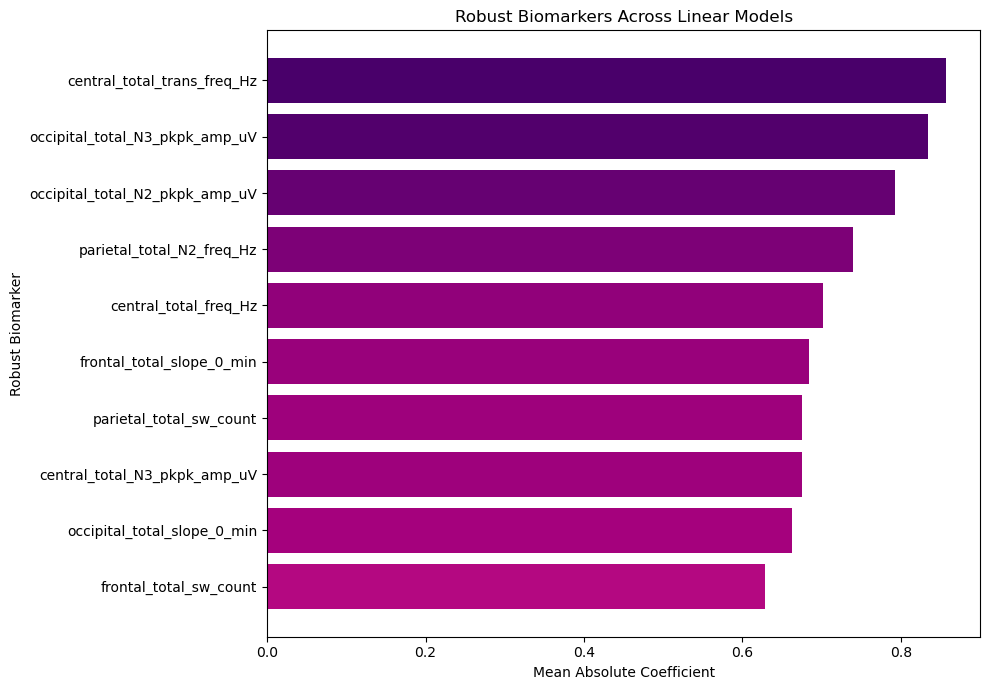

In [34]:
# la figure 
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.RdPu(
    robust["mean_abs_coefficient"] /
    robust["mean_abs_coefficient"].max()
)

ax.barh(
    robust["feature"],
    robust["mean_abs_coefficient"],
    color=colors
)

ax.set_xlabel("Mean Absolute Coefficient")
ax.set_ylabel("Robust Biomarker")
ax.set_title("Robust Biomarkers Across Linear Models")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "robust_biomarkers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# Model Comparison Figure

In [36]:
# on charge le tableau 
comparison = pd.read_csv(
    ML_RESULTS_DIR / "model_comparison.csv",
    index_col=0
)

comparison

,Linear_SVM,Logistic_Regression
accuracy,0.687500,0.578125
balanced_accuracy,0.682186,0.577935
precision,0.607143,0.483871
recall,0.653846,0.576923
f1,0.629630,0.526316
roc_auc,0.727733,0.641700


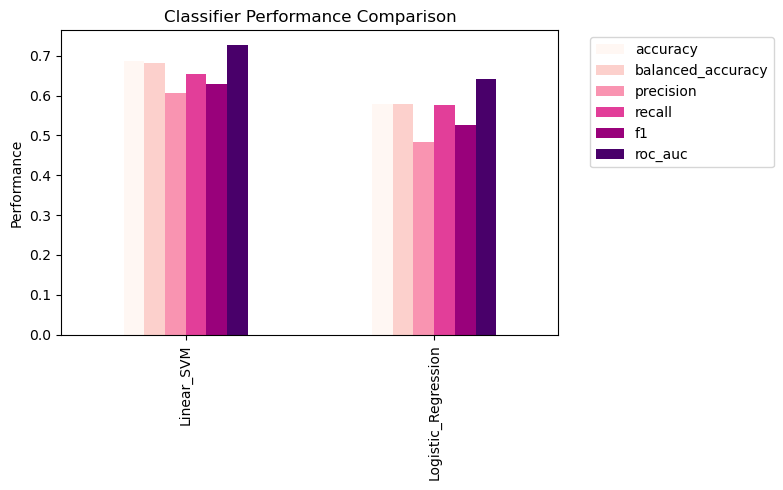

In [37]:
# on créée la figure 
fig, ax = plt.subplots(
    figsize=(8, 5)
)

comparison.T.plot(
    kind="bar",
    ax=ax,
    colormap="RdPu"
)

ax.set_ylabel(
    "Performance"
)

ax.set_title(
    "Classifier Performance Comparison"
)

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# Integrated Biomarker Discovery Workflow

In [39]:
from matplotlib.patches import FancyBboxPatch

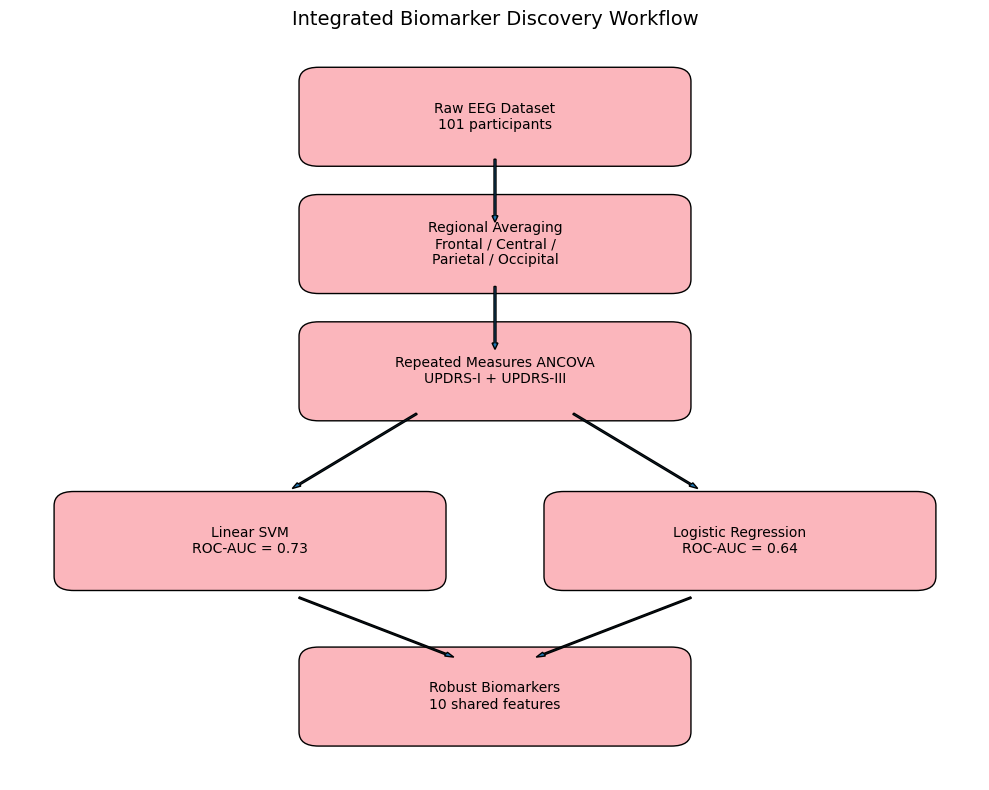

In [40]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.axis("off")

steps = [
    (
        "Raw EEG Dataset\n101 participants",
        0.5,
        0.90
    ),
    (
        "Regional Averaging\nFrontal / Central /\nParietal / Occipital",
        0.5,
        0.72
    ),
    (
        "Repeated Measures ANCOVA\nUPDRS-I + UPDRS-III",
        0.5,
        0.54
    ),
    (
        "Linear SVM\nROC-AUC = 0.73",
        0.25,
        0.30
    ),
    (
        "Logistic Regression\nROC-AUC = 0.64",
        0.75,
        0.30
    ),
    (
        "Robust Biomarkers\n10 shared features",
        0.5,
        0.08
    ),
]

for label, x, y in steps:

    box = FancyBboxPatch(
        (
            x - 0.18,
            y - 0.05
        ),
        0.36,
        0.10,
        boxstyle="round,pad=0.02",
        facecolor=plt.cm.RdPu(0.3),
        edgecolor="black"
    )

    ax.add_patch(box)

    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=10
    )

ax.arrow(
    0.5,
    0.84,
    0,
    -0.08,
    width=0.002
)

ax.arrow(
    0.5,
    0.66,
    0,
    -0.08,
    width=0.002
)

ax.arrow(
    0.42,
    0.48,
    -0.12,
    -0.10,
    width=0.002
)

ax.arrow(
    0.58,
    0.48,
    0.12,
    -0.10,
    width=0.002
)

ax.arrow(
    0.30,
    0.22,
    0.15,
    -0.08,
    width=0.002
)

ax.arrow(
    0.70,
    0.22,
    -0.15,
    -0.08,
    width=0.002
)

ax.set_title(
    "Integrated Biomarker Discovery Workflow",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "biomarker_discovery_workflow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
# Regional vs Global Model Comparison

In [42]:
comparison = pd.read_csv(
    ML_RESULTS_DIR /
    "regional_vs_global_comparison.csv",
    index_col=0
)

comparison

,Regional_SVM,Global_SVM
accuracy,0.687500,0.562500
balanced_accuracy,0.682186,0.565833
precision,0.607143,0.450000
recall,0.653846,0.580645
f1,0.629630,0.507042
roc_auc,0.727733,0.549704


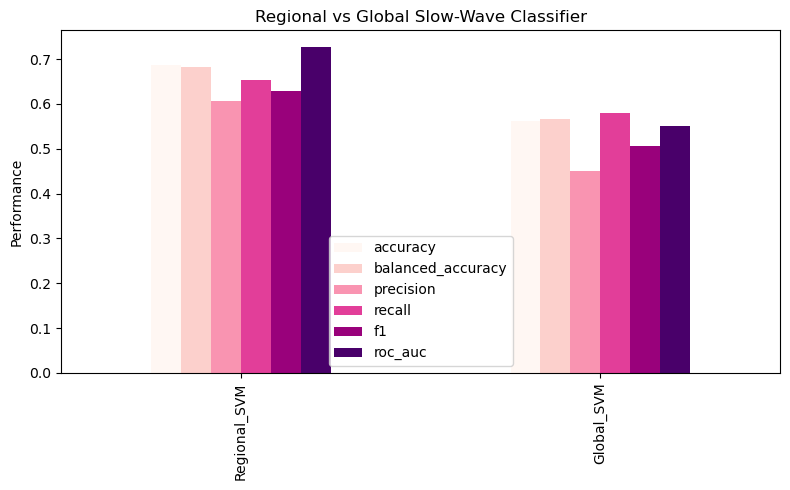

In [43]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

comparison.T.plot(
    kind="bar",
    ax=ax,
    colormap="RdPu"
)

ax.set_ylabel(
    "Performance"
)

ax.set_title(
    "Regional vs Global Slow-Wave Classifier"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "regional_vs_global_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()